### **Evaluation of symbolic music generation metrics<br>** *Evaluation phase*
**Author:** Fabian Lohmann (student ID: 852760749)<br>
**Course:** Generative Artificial Intelligence (IM1412), Open University of the Netherlands<br>
*August 2026*

**Requirements:** `Bach_model.pt` and `gen_chorales.json` as generated by the training notebook, and `jsb-chorales-16th.pkl` from the JSB-chorales dataset (https://github.com/czhuang/JSB-Chorales-dataset).

This notebook evaluates the quality of the chorales generated with the model created in the training notebook using objective metrics common to symbolic music generation literature.

Three metric families are compared:
1. **Distributional metrics** (MusPy): the standard in symbolic music generation research
2. **Rule-based metrics**: based on voice-leading rules from chorale-style counterpoint, introduced for this study
3. **Model likelihood** (NLL / perplexity): the metric reported by the Music Transformer and NotaGen

These metrics are applied on:
1. **Real Bach**: 77 chorales withheld from training
2. **Shuffled Bach**: 77 Bach chorales from the test set with their bars randomly reordered
3. **Generated**: 77 chorales generated with the trained model

Additionally, a segment-boundary interval analysis is performed. Because shuffled chorales are no longer continuous at the boundaries between bars, an analysis of pitch intervals at these boundaries is performed.

Finally, the data is visualized and the distributional and rule-based metrics are statistically tested.

**Disclaimer:** This code was written with the assistance of Claude AI. All code was rewritten, annotated, verified and fully understood by the author.

#### 1. Dependencies and initialization
The hyperparameters and several functions from the training notebook are being reused.

In [1]:
import pickle, random, json, os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pretty_midi, muspy
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import shutil
from scipy.stats import mannwhitneyu
from scipy.stats import fisher_exact
from music21 import chord as m21chord

# Set hyperparameters that match the training notebook
SEED = 1427
VOCAB_SIZE = 49
SEQ_LEN = 256
PITCH_MIN = 36
REST, BOS, EOS = 0, 47, 48
D_MODEL = 192
NHEAD = 4
NUM_LAYERS = 4
DIM_FF = 768
DROPOUT = 0.1

# Initialize random seed
random.seed(SEED)
np.random.seed(SEED)

# Initialize torch device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


#### 2. Preparing the evaluation data
The real and generated Bach chorales are loaded, and the shuffled Bach chorales are created by randomly reordering the bars of test chorales.
These sets are subsequently converted into MIDI, which is necessary for the distributional metrics because MusPy reads MIDI. 

In [2]:
### Setting up the chorales ###

# Load the JSB-Chorales database
with open('jsb-chorales-16th.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

# Extract the test set
test_chorales = [
    [tuple(int(p) for p in ts) for ts in ch]
    for ch in data['test']
]

# Load the generated chorales set (and exclude any potential empty generations)
with open('gen_chorales.json', 'r') as f:
    raw = json.load(f)
    gen_chorales = [
        [tuple(ts) for ts in ch] for ch in raw 
        if len(ch) > 0 and any(p is not None for ts in ch for p in ts)
    ]
    dropped = len(raw) - len(gen_chorales)
    if dropped > 0:
        print(f'Note: {dropped} empty chorales excluded')

# Shuffles chorales by bars
def shuffle_bars(chorale, steps_per_bar=16):
    # Split into full bars and a remainder
    n_full = len(chorale) // steps_per_bar
    full_bars = [chorale[i * steps_per_bar : (i + 1) * steps_per_bar] for i in range(n_full)]
    remainder = chorale[n_full * steps_per_bar:]
    
    # Shuffle only the full bars
    random.shuffle(full_bars)
    
    # Reassemble with the remainder put at the end
    shuffled_chorale = []
    for bar in full_bars:
        for timestep in bar:
            shuffled_chorale.append(timestep)
    shuffled_chorale.extend(remainder)
    
    return shuffled_chorale

# Create the shuffled chorales set
shuffled_chorales = [shuffle_bars(ch) for ch in test_chorales]

print(f'Real Bach:  {len(test_chorales)} chorales')
print(f'Shuffled:   {len(shuffled_chorales)} chorales')
print(f'Generated:  {len(gen_chorales)} chorales')

Real Bach:  77 chorales
Shuffled:   77 chorales
Generated:  77 chorales


In [3]:
# Converts a chorale into a MIDI file, necessary for MusPy 
def chorale_to_midi(chorale, path, bpm=80):
    pm = pretty_midi.PrettyMIDI(initial_tempo=bpm)      # Creates empty MIDI file
    step = (60.0 / bpm) / 4                             # Sets duration of a 16th note
    for v in range(4):                                  # Loop through the four tracks
        inst = pretty_midi.Instrument(program=52)       # Choir sound

        # Extract full music sequence for one track
        seq = []
        for timestep in chorale:
            if len(timestep) > v:
                seq.append(timestep[v])
            else:
                seq.append(None)

        # Make sure that a note keeps being held if subsequent timesteps contain the same pitch
        cur, start = None, 0.0          # Initialize
        for i, p in enumerate(seq + [None]):    # For every pitch in the sequence
            t = i * step                        # Convert timestep index to seconds
            if p != cur:                        # If the pitch has changed
                if cur is not None:             # If a note should be held on to,
                    inst.notes.append(pretty_midi.Note(90, int(cur), start, t)) # write from start to t
                cur, start = p, t

        pm.instruments.append(inst)     # Add complete track to MIDI file

    pm.write(path)      # Save the MIDI file

# Create directories for MIDI files
for folder in ['midi_real', 'midi_generated', 'midi_shuffled']:
    if os.path.exists(folder):      # Wipe folders if they already exist to avoid outdated files from remaining
        shutil.rmtree(folder)
    os.makedirs(folder)

# Convert all chorales into MIDI files
for i, ch in enumerate(test_chorales):
    chorale_to_midi(ch, f'midi_real/real_{i:03d}.mid')
for i, ch in enumerate(gen_chorales):
    chorale_to_midi(ch, f'midi_generated/gen_{i:03d}.mid')
for i, ch in enumerate(shuffled_chorales):
    chorale_to_midi(ch, f'midi_shuffled/shuffled_{i:03d}.mid')

print(f'Exported: {len(os.listdir("midi_real"))} real, '
      f'{len(os.listdir("midi_shuffled"))} shuffled, '
      f'{len(os.listdir("midi_generated"))} generated')

real_lengths = [len(ch) for ch in test_chorales]
gen_lengths = [len(ch) for ch in gen_chorales]

print()
print("Chorale lengths (timesteps):")
print(f'Real Bach:  min {min(real_lengths)}, max {max(real_lengths)}, mean {np.mean(real_lengths):.0f}')
print(f'Generated:  min {min(gen_lengths)}, max {max(gen_lengths)}, mean {np.mean(gen_lengths):.0f}')

Exported: 77 real, 77 shuffled, 77 generated

Chorale lengths (timesteps):
Real Bach:  min 128, max 640, mean 245
Generated:  min 5, max 400, mean 85


#### 3. Distributional metrics (MusPy)
Standard metrics used in symbolic music generation literature that measure statistical properties of a music piece: 
- **Pitch class entropy**: distribution of pitch classes
- **Scale consistency**: fraction of notes that fit within a single scale
- **Polyphony**: average number of notes that are simultaneously present per timestep
- **Pitch range**: distance in semitones between the lowest and highest note in the piece

In [4]:
# Calculates the distributional metrics of all MIDI files in a folder
def eval_distributional(folder):
    results = []
    
    # For each file in the folder, calculate all metrics
    for f in sorted(os.listdir(folder)):
        
        # Read file
        m = muspy.read_midi(os.path.join(folder, f))
        
        # Checks if any MIDI tracks are invalid due to being empty and skips those
        if len(m.tracks) == 0 or all(len(t.notes) == 0 for t in m.tracks):
            continue
        
        # Add metrics to results dictionary
        results.append({
            'pitch_class_entropy': muspy.pitch_class_entropy(m),
            'scale_consistency': muspy.scale_consistency(m),
            'pitch_range': muspy.pitch_range(m),
            'polyphony': muspy.polyphony(m),
        })

    print(f'{folder}: {len(results)} valid out of {len(os.listdir(folder))} files')
    return pd.DataFrame(results)

# Calculate for each of the dataset folders
dist_real = eval_distributional('midi_real')
dist_shuf = eval_distributional('midi_shuffled')
dist_gen = eval_distributional('midi_generated')

summary = pd.DataFrame({
    'Real Bach': dist_real.mean(),
    'Shuffled': dist_shuf.mean(),
    'Generated': dist_gen.mean(),
})
print()
print(summary.round(4))

midi_real: 77 valid out of 77 files
midi_shuffled: 77 valid out of 77 files
midi_generated: 77 valid out of 77 files

                     Real Bach  Shuffled  Generated
pitch_class_entropy     3.0260    3.0209     2.9850
scale_consistency       0.9297    0.9301     0.9032
pitch_range            34.3506   34.3506    32.6104
polyphony               3.9231    3.9231     3.8173


#### 4. Rule-based metrics
Whereas distributional metrics are based on statistics, this section introduces metrics based on established conventions in counterpoint: 
- **Voice crossing**: In chorales, the pitch of each voice should ideally be hierarchical at each timestep. The soprano should always be higher than the alto, etc. in accordance with SATB (soprano > alto > tenor > bass). This metric measures how often the voice registers are crossed.
- **Parallel fifths**: When two voices remain a perfect fifth (7 semitones) or an octave/unison apart during consecutive distinct notes, they lose their independent melodies. Bach avoided this meticulously. This metric measures how often this occurs.
- **Proper cadence**: In Bach chorales, the final chord is often a root-position major or minor triad, with the bass on the chord root, which gives a sense of resolution to the piece. This metric counts in how many chorales of a set this is the case. 

In [5]:
# Voice crossing metric i.e. the fraction of timesteps wherein voices are not in the SATB pitch order
def voice_crossing_rate(chorale):
    crossings = 0           # Counts the number of crossings
    total = 0               # Counts the number of timesteps that have passed
    for timestep in chorale:
        if len(timestep) == 4 and all(p is not None for p in timestep):     # Check if timestep has four voices and all are playing a note
            total += 1 
            if not (timestep[0] >= timestep[1] >= timestep[2] >= timestep[3]):  # Check if there are any SATB crossings
                crossings += 1
    return crossings / total if total > 0 else 0        # Fraction: crossings divided by total timesteps checked

# Parallel fifths metric i.e. the fraction of consecutive transitions between two voices that maintain parallel fifths or octaves
def parallel_fifths_rate(chorale):
    violations = 0      # Counts the number of consecutive parallel fifths or octaves
    checked = 0         # Counts every checked pair of voices
    
    for timestep in range(len(chorale) - 1):
        ts1, ts2 = chorale[timestep], chorale[timestep + 1]   # Current and next timestep
        
        # Skip timesteps with fewer than 4 voices
        if len(ts1) < 4 or len(ts2) < 4:        
            continue
        
        # Skip timesteps that contain rests
        if any(p is None for p in ts1) or any(p is None for p in ts2):  
            continue
        
        # Compare each voice pair in the timestep
        for v1 in range(4):
            for v2 in range(v1 + 1, 4):
                
                # Compute the in-octave pitch difference between both voices at current and next timestep
                interval1 = abs(ts1[v1] - ts1[v2]) % 12
                interval2 = abs(ts2[v1] - ts2[v2]) % 12
                
                # Check if both voices are a fifth or an octave apart and remain so during both timesteps
                if interval1 in (0, 7) and interval1 == interval2:
                    if ts1[v1] != ts2[v1] and ts1[v2] != ts2[v2]:   # Do not count if both timesteps contain the same note
                        violations += 1
                checked += 1
                
    return violations / checked if checked > 0 else 0   # Fraction

# Cadence quality metric i.e. checks in how many chorales of a set the final sonority is a root-position major or minor triad
def cadence_quality(chorale):
    # Find the last timestep with all four voices sounding
    final = None
    for ts in reversed(chorale):
        if len(ts) == 4 and all(p is not None for p in ts):
            final = ts
            break
    if final is None:
        return False
    
    # Analyze the chord using music21
    c = m21chord.Chord(list(final))
    
    # Must be a major or minor triad
    if not (c.isMajorTriad() or c.isMinorTriad()):
        return False
    
    # The lowest sounding pitch must be the root position
    root = c.root()
    lowest = min(final)
    if root is None:
        return False
    
    return (lowest % 12) == (root.midi % 12)

# Compute voice crossings metric for all chorales
vc_real = [voice_crossing_rate(ch) for ch in test_chorales]
vc_shuf = [voice_crossing_rate(ch) for ch in shuffled_chorales]
vc_gen = [voice_crossing_rate(ch) for ch in gen_chorales]

# Compute parallel fifths metrics for all chorales
pf_real = [parallel_fifths_rate(ch) for ch in test_chorales]
pf_shuf = [parallel_fifths_rate(ch) for ch in shuffled_chorales]
pf_gen = [parallel_fifths_rate(ch) for ch in gen_chorales]

# Compute cadence quality metrics for all chorales
cad_real = [cadence_quality(ch) for ch in test_chorales]
cad_shuf = [cadence_quality(ch) for ch in shuffled_chorales]
cad_gen = [cadence_quality(ch) for ch in gen_chorales]

print('Voice crossing rate:')
print(f'  Real Bach: {np.mean(vc_real):.4f}')
print(f'  Shuffled:  {np.mean(vc_shuf):.4f}')
print(f'  Generated: {np.mean(vc_gen):.4f}')
print()
print('Parallel fifths/octaves rate:')
print(f'  Real Bach: {np.mean(pf_real):.4f}')
print(f'  Shuffled:  {np.mean(pf_shuf):.4f}')
print(f'  Generated: {np.mean(pf_gen):.4f}')
print()
print(f'Proper cadence (root-position triad):')
print(f'  Real Bach: {sum(cad_real)}/{len(cad_real)} ({sum(cad_real)/len(cad_real)*100:.1f}%)')
print(f'  Shuffled:  {sum(cad_shuf)}/{len(cad_shuf)} ({sum(cad_shuf)/len(cad_shuf)*100:.1f}%)')
print(f'  Generated: {sum(cad_gen)}/{len(cad_gen)} ({sum(cad_gen)/len(cad_gen)*100:.1f}%)')

Voice crossing rate:
  Real Bach: 0.0211
  Shuffled:  0.0211
  Generated: 0.1422

Parallel fifths/octaves rate:
  Real Bach: 0.0004
  Shuffled:  0.0026
  Generated: 0.0059

Proper cadence (root-position triad):
  Real Bach: 75/77 (97.4%)
  Shuffled:  62/77 (80.5%)
  Generated: 17/77 (22.1%)


#### 5. Segment-boundary interval analysis
Because in shuffled chorales the connections between bars are broken, an analysis is carried out that quantifies the jumps in pitch at this boundary for the soprano voice. The soprano voice is chosen because this is the most prominent voice in chorales that often carries the main melody. Real Bach is compared to the shuffled chorales to see if there is any significant difference and to consider if this may be a measure of longer term musical structure as this is the only metric that measures musical continuity.

For this analysis, 16 step segments are used, which would coincide with a 4/4 time signature. Although not all chorales adhere to the 4/4 time signature, this does not affect the validity of the comparison, as the shuffling of fixed-length segments would affect sequential continuity regardless.

In [6]:
# Counts pitch intervals both within bars and at bar boundaries
def soprano_intervals_by_position(chorale, steps_per_bar=16):
    within = []         # Collects the pitch intervals within bars
    boundary = []       # Collects the pitch intervals at bar boundaries
    
    # Loop through every pair of consecutive timesteps in the chorale
    for timestep in range(len(chorale) - 1):
        
        # Skip any empty tuples
        if len(chorale[timestep]) < 1 or len(chorale[timestep+1]) < 1:
            continue
        
        # Extract the soprano voice (index 0) at both consecutive timesteps
        s1, s2 = chorale[timestep][0], chorale[timestep+1][0]
        
        # Skip timesteps with REST tokens
        if s1 is None or s2 is None:
            continue
        
        # Calculate the pitch interval between both timesteps
        interval = abs(int(s2) - int(s1))
        
        # Add the pitch interval to their appropriate category 
        if (timestep + 1) % steps_per_bar == 0:
            boundary.append(interval)
        else:
            within.append(interval)

    return within, boundary

# Create empty lists for the pitch intervals in each category of chorale 
within_real, boundary_real = [], []
within_shuf, boundary_shuf = [], []
within_gen, boundary_gen = [], []

# Go through every chorale and fill the lists with all the pitch intervals
for ch in test_chorales:
    w, b = soprano_intervals_by_position(ch)
    within_real.extend(w); boundary_real.extend(b)
for ch in shuffled_chorales:
    w, b = soprano_intervals_by_position(ch)
    within_shuf.extend(w); boundary_shuf.extend(b)
for ch in gen_chorales:
    w, b = soprano_intervals_by_position(ch)
    within_gen.extend(w); boundary_gen.extend(b)

# Aggregate to per-chorale mean intervals, so subsequent significance tests can run on n=77 chorales
def per_chorale_intervals(chorales, steps_per_bar=16):
    within_pc, boundary_pc = [], []
    for ch in chorales:
        w, b = soprano_intervals_by_position(ch, steps_per_bar)
        
        # If there are any chorales with less than one bar, assign NaN as these do not contain segment boundaries
        within_pc.append(np.mean(w) if len(w) > 0 else np.nan)      
        boundary_pc.append(np.mean(b) if len(b) > 0 else np.nan)    
    return within_pc, boundary_pc

within_real, boundary_real = per_chorale_intervals(test_chorales)
within_shuf, boundary_shuf = per_chorale_intervals(shuffled_chorales)
within_gen,  boundary_gen  = per_chorale_intervals(gen_chorales)

# Calculate the mean intervals for each category and print
print('Mean soprano interval (semitones), averaged over chorales:')
print(f'{"":>20} {"Within bar":>12} {"At boundary":>12} {"Ratio":>8}')
print('-' * 55)
for name, w, b in [
    ('Real Bach', within_real, boundary_real),
    ('Shuffled', within_shuf, boundary_shuf),
    ('Generated', within_gen, boundary_gen),
]:
    mw, mb = np.nanmean(w), np.nanmean(b)       # NaNmean skips the chorales marked NaN above
    print(f'{name:>20} {mw:>12.3f} {mb:>12.3f} {mb/mw:>8.2f}')

# List the number of chorales with less than one bar, if any
print()
print("Chorales with a length of less than one bar:")
for i, ch in enumerate(gen_chorales):
    w, b = soprano_intervals_by_position(ch)
    if len(b) == 0:
        print(f'chorale {i}: length {len(ch)}, bars {len(ch)//16}')

Mean soprano interval (semitones), averaged over chorales:
                       Within bar  At boundary    Ratio
-------------------------------------------------------
           Real Bach        0.342        1.829     5.35
            Shuffled        0.342        3.595    10.52
           Generated        0.457        2.139     4.68

Chorales with a length of less than one bar:
chorale 51: length 14, bars 0
chorale 76: length 5, bars 0


#### 6. Model likelihood (NLL / Perplexity)
NLL is calculated by feeding a sequence of tokens into the model, and comparing the model's predictions to the actual next token. Perplexity is the exponential of NLL. Higher NLL / perplexity indicates less resemblance to the model. Because the shuffled chorales mainly shuffle the structure of the pieces, higher NLL for the shuffled pieces should indicate that the model learned structural cohesiveness.

Model likelihood is not calculated for the generated chorales, as these have been generated by the model itself. Scoring generated chorales would not reveal anything because the model would always score its own samples as likely.

To calculate this, the model (`Bach_model.pt`) created in the training notebook is first loaded.

In [7]:
# Remove internal PyTorch optimization error that is not applicable to this setup
import warnings
warnings.filterwarnings("ignore", message="enable_nested_tensor")

# Set up the transformer
class ChoralTransformer(nn.Module):
    # Parameters
    def __init__(self, vocab_size=VOCAB_SIZE, d_model=D_MODEL, nhead=NHEAD,
                 num_layers=NUM_LAYERS, dim_ff=DIM_FF, dropout=DROPOUT, max_len=SEQ_LEN):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, vocab_size)

    # Forward loop
    def forward(self, x):
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        x = self.token_emb(x) + self.pos_emb(pos)
        mask = nn.Transformer.generate_square_subsequent_mask(T, device=x.device)
        x = self.transformer(x, mask=mask, is_causal=True)
        return self.head(x)

# Load the model
model = ChoralTransformer().to(device)
model.load_state_dict(torch.load('Bach_model.pt', map_location=device))
model.eval()
print('Model loaded.')

Model loaded.


In [8]:
# Convert MIDI pitch number to corresponding token value
def pitch_to_tok(p):
    return p - PITCH_MIN + 1

# Flatten a chorale into a sequence of tokens
def encode(chorale):
    toks = [BOS]                    # Start with BOS token
    for timestep in chorale:        # For each timestep tuple, assign all pitch values to token sequence                    
        voices = list(timestep) + [None] * (4 - len(timestep))
        for p in voices:
            if p is not None:
                toks.append(pitch_to_tok(int(p)))
            else:
                toks.append(REST)   # Empty tokens get assigned token 0 (REST)
    toks.append(EOS)                # End sequence with EOS token
    return toks

# Compute mean NLL and perplexity
def compute_nll(model, chorales):
    model.eval()                    # Evaluation mode to disable dropout
    losses = []             
    with torch.no_grad():           # Stops PyTorch from tracking gradients to save memory
        for ch in chorales:     
            tokens = encode(ch)     # Convert chorale into token sequence
            
            # Split up token sequence into chunks of length SEQ_LEN + 1 for loss calculation
            for i in range(0, len(tokens) - SEQ_LEN, SEQ_LEN):      
                chunk = tokens[i : i + SEQ_LEN + 1]
                x = torch.tensor([chunk[:-1]], device=device)
                y = torch.tensor([chunk[1:]], device=device)
                loss = nn.functional.cross_entropy(model(x).view(-1, VOCAB_SIZE), y.view(-1))
                losses.append(loss.item())
    mean_nll = np.mean(losses)          # Find mean loss, which is the NLL
    return mean_nll, np.exp(mean_nll)   # PPL is the exponential of NLL

# Compute the NLL and PPL of the real Bach chorales and the shuffled chorales
nll_real, ppl_real = compute_nll(model, test_chorales)
nll_shuf, ppl_shuf = compute_nll(model, shuffled_chorales)

print(f'Real Bach  NLL: {nll_real:.4f}, PPL: {ppl_real:.4f}')
print(f'Shuffled   NLL: {nll_shuf:.4f}, PPL: {ppl_shuf:.4f}')
print(f'Difference NLL: {nll_shuf - nll_real:+.4f} ({(nll_shuf - nll_real) / nll_real * 100:+.1f}%)')

Real Bach  NLL: 0.5583, PPL: 1.7477
Shuffled   NLL: 0.6167, PPL: 1.8528
Difference NLL: +0.0584 (+10.5%)


#### 7. Visualizations

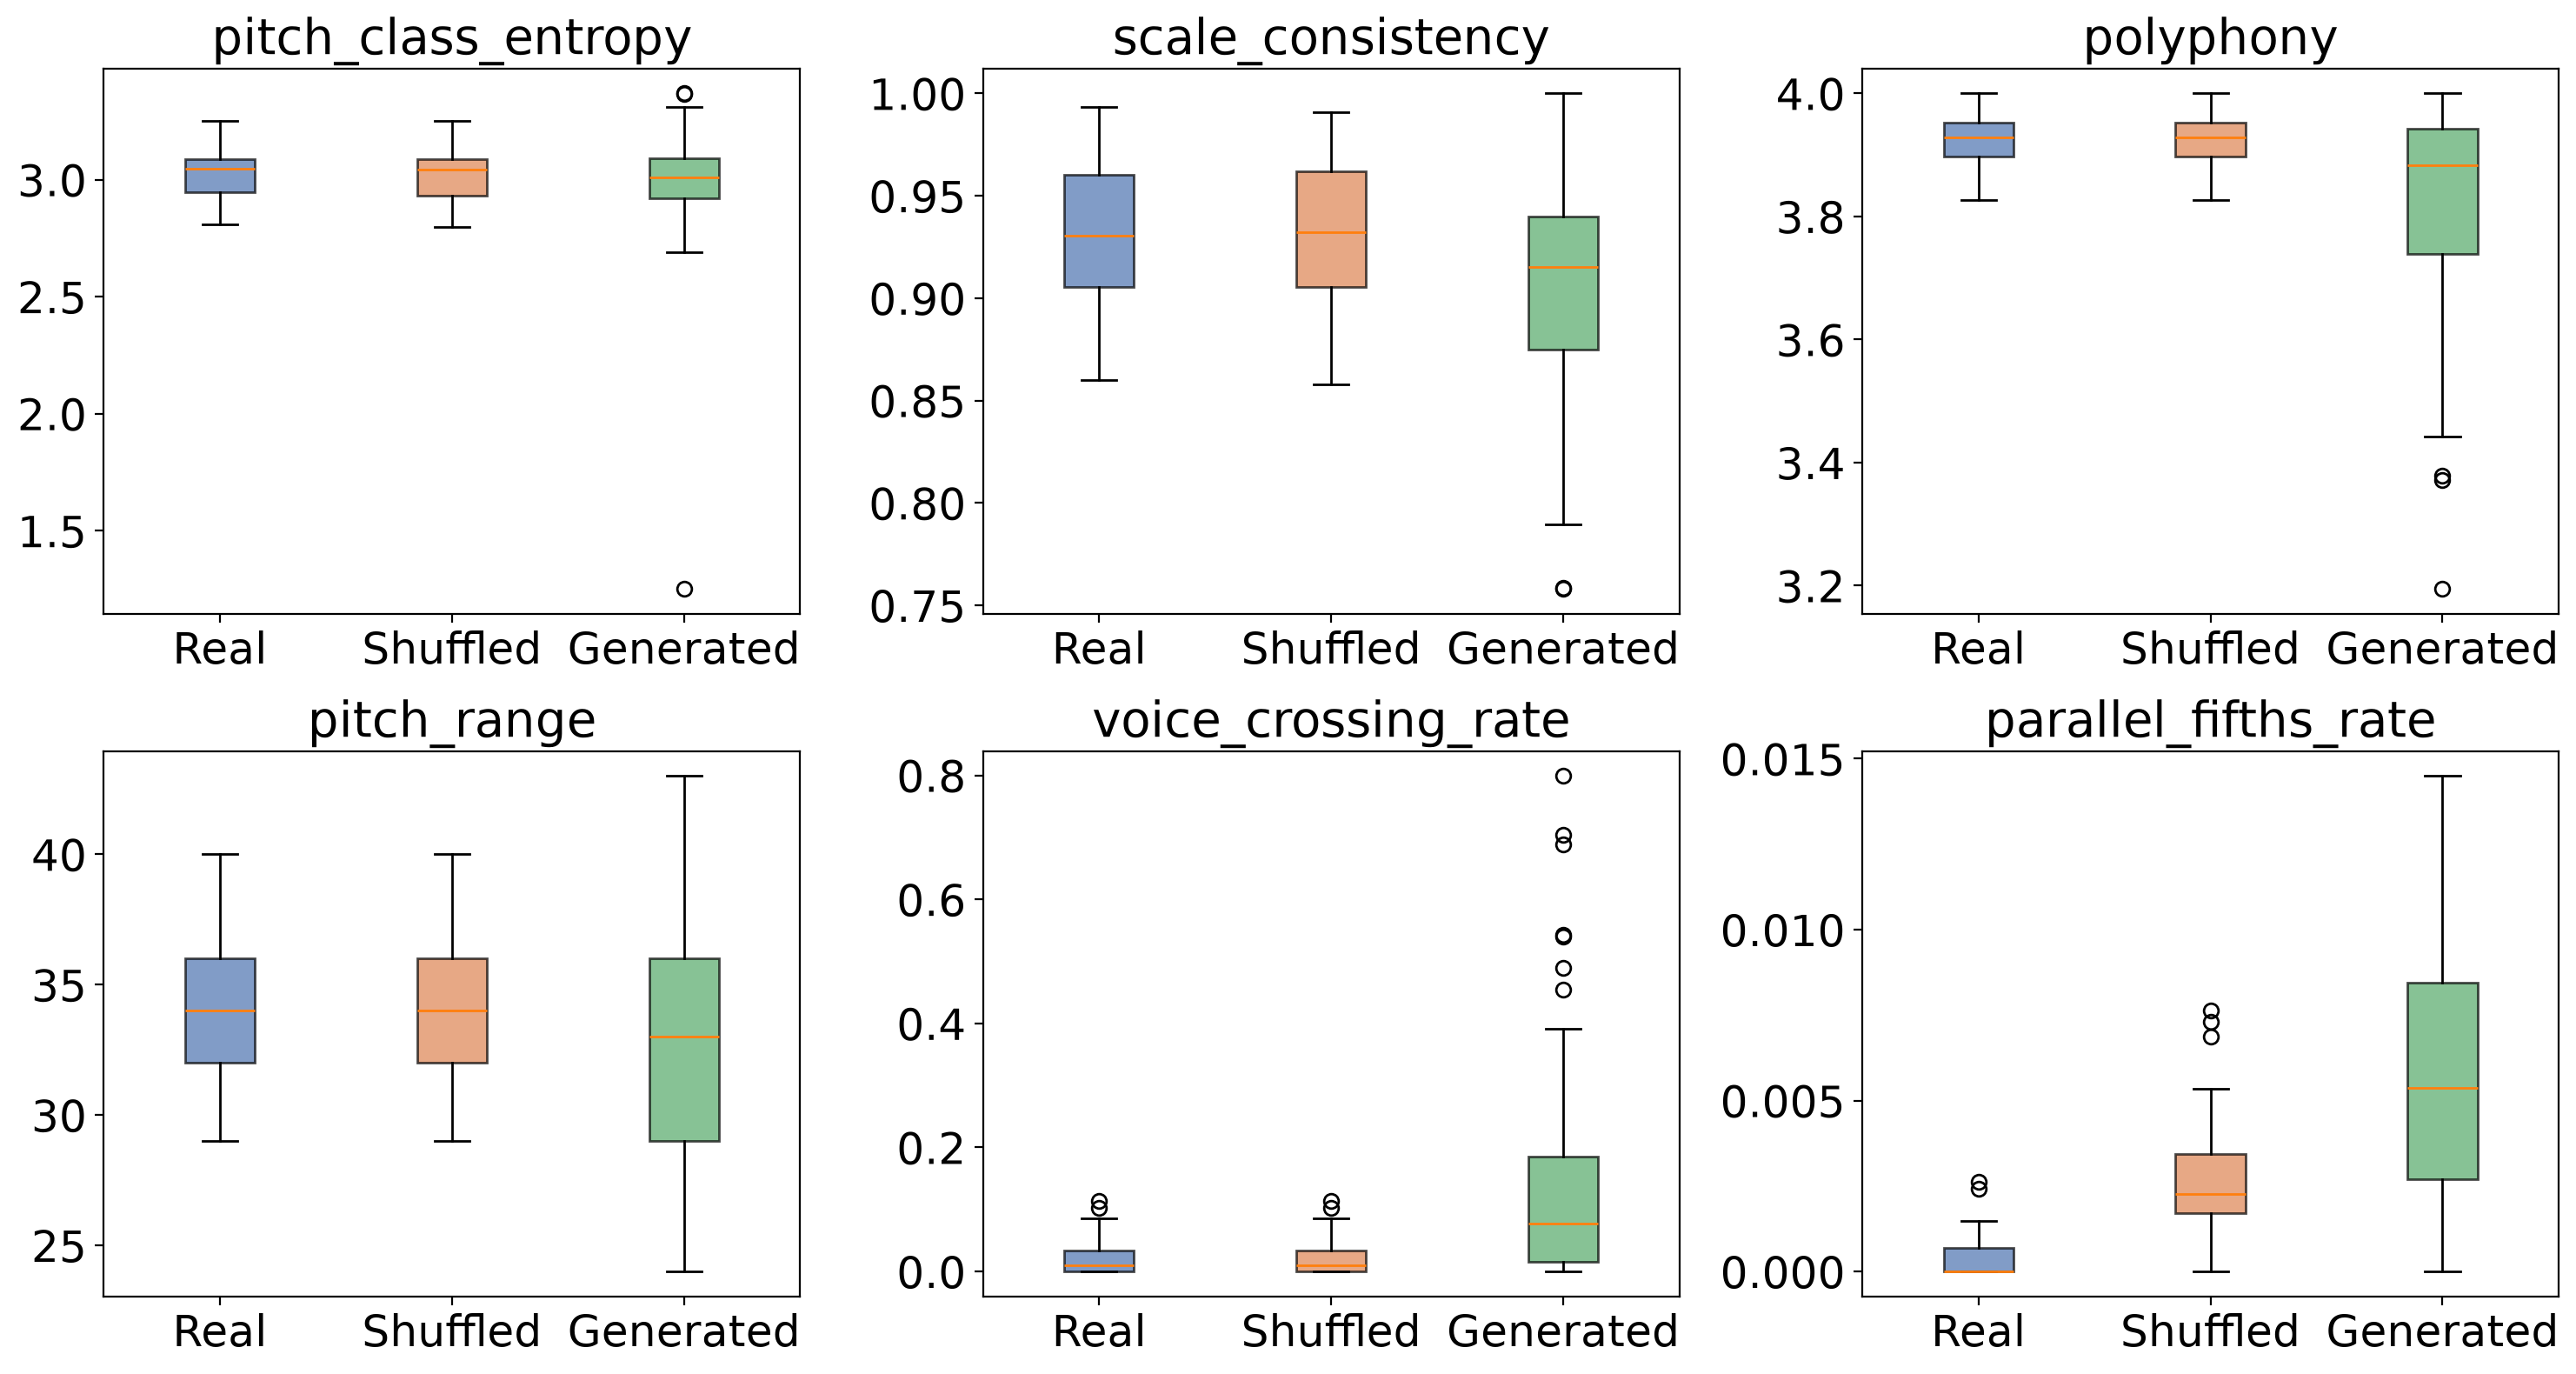

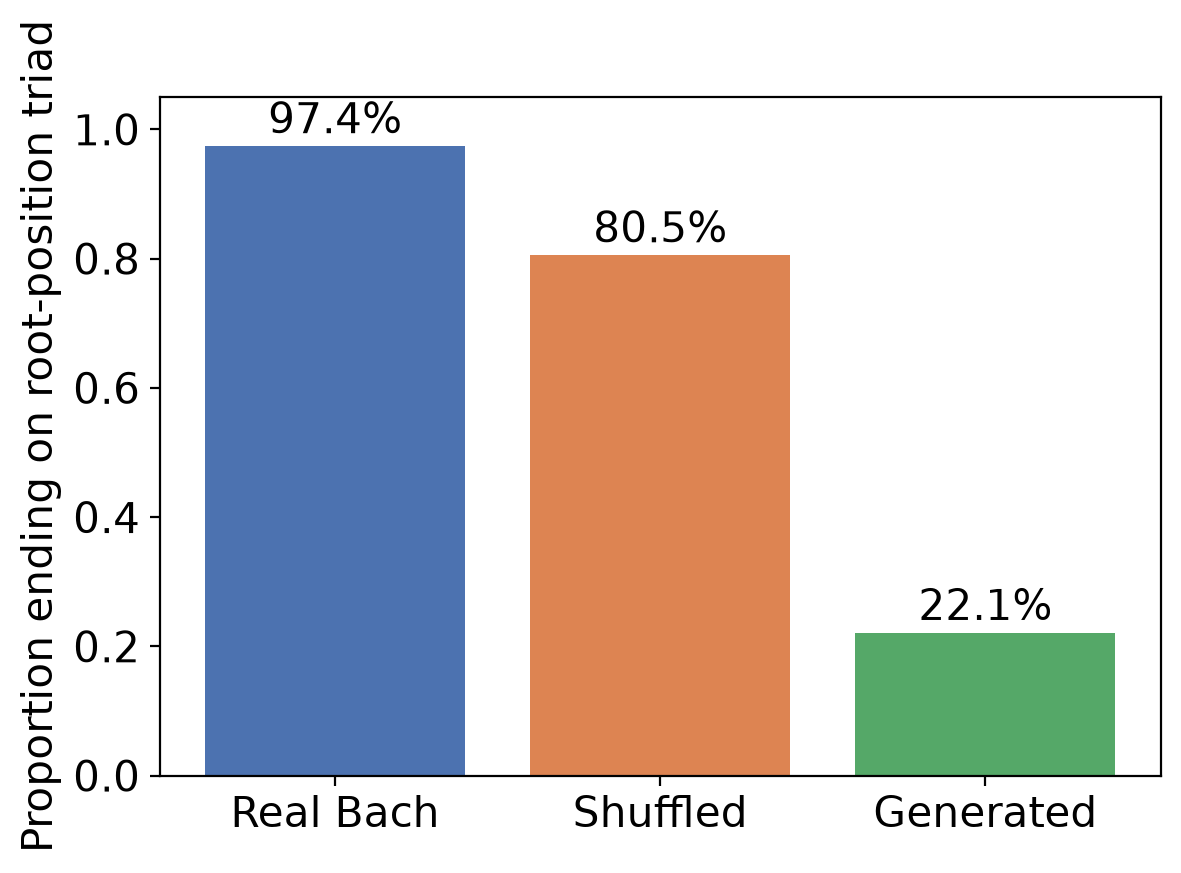

Soprano: MIDI 60–81, median 71
Alto: MIDI 52–74, median 65
Tenor: MIDI 43–69, median 59
Bass: MIDI 36–66, median 50


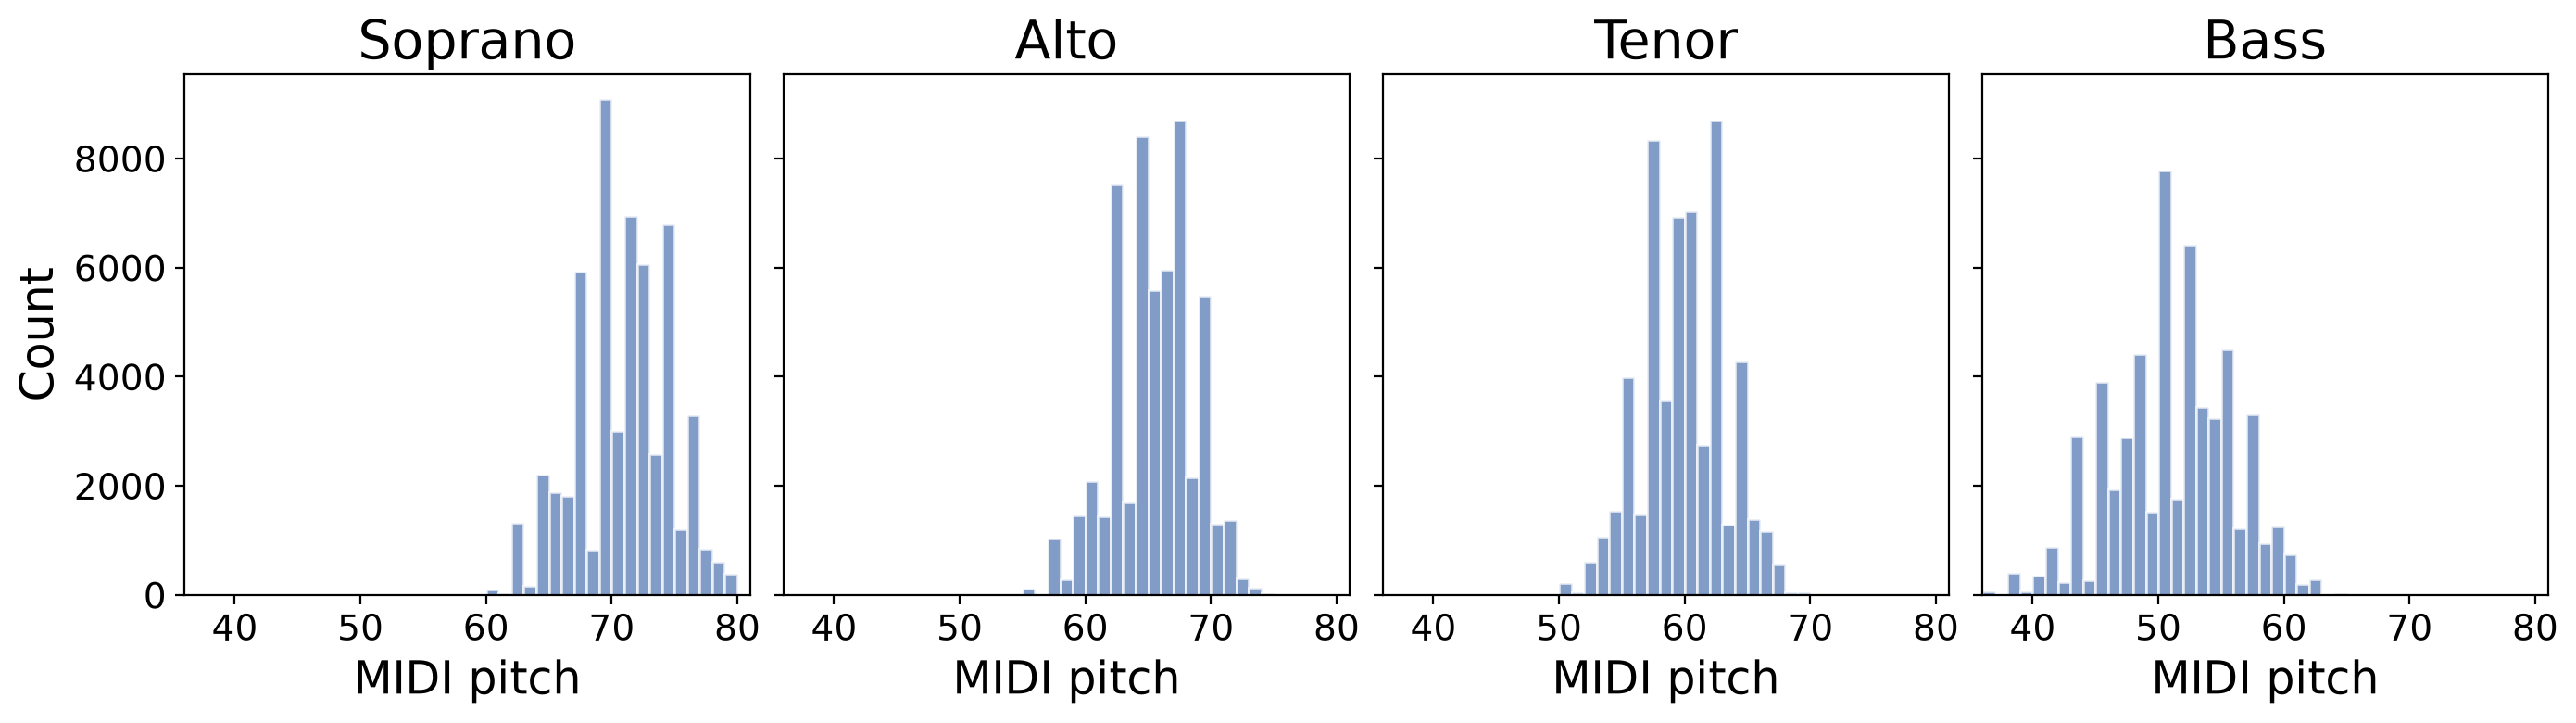

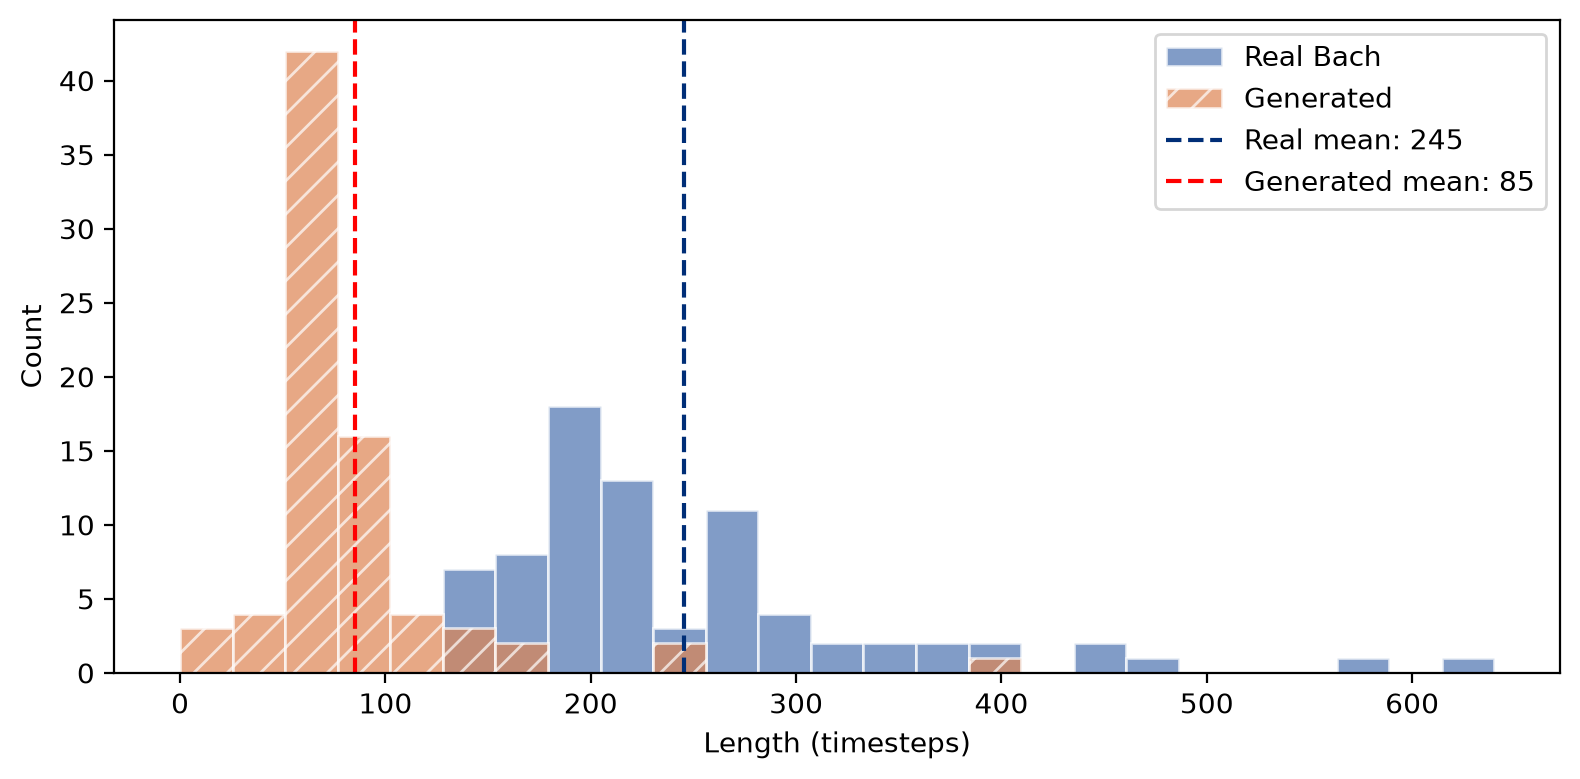

In [ ]:
# Visual plots of all metrics

# Distributional and rule-based metrics
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, metric in enumerate(['pitch_class_entropy', 'scale_consistency', 'polyphony']):
    ax = axes[0, i]
    bp = ax.boxplot(
        [dist_real[metric], dist_shuf[metric], dist_gen[metric]],
        tick_labels=['Real', 'Shuffled', 'Generated'],
        patch_artist=True
    )
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(metric, fontsize=20)
    ax.tick_params(axis='both', labelsize=18)

for i, (name, real, shuf, gen) in enumerate([
    ('pitch_range', dist_real['pitch_range'].tolist(), dist_shuf['pitch_range'].tolist(), dist_gen['pitch_range'].tolist()),
    ('voice_crossing_rate', vc_real, vc_shuf, vc_gen),
    ('parallel_fifths_rate', pf_real, pf_shuf, pf_gen),
]):
    ax = axes[1, i]
    bp = ax.boxplot(
        [real, shuf, gen],
        tick_labels=['Real', 'Shuffled', 'Generated'],
        patch_artist=True
    )
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(name, fontsize=20)
    ax.tick_params(axis='both', labelsize=18)

plt.tight_layout()
plt.savefig('metric_comparison_boxplots.pdf', dpi=150)
plt.savefig('metric_comparison_boxplots.png', dpi=150)
plt.show()

# Cadence quality
fig, ax = plt.subplots(figsize=(6, 4))
systems = ['Real Bach', 'Shuffled', 'Generated']
rates = [sum(cad_real)/len(cad_real), sum(cad_shuf)/len(cad_shuf), sum(cad_gen)/len(cad_gen)]
bars = ax.bar(systems, rates, color=colors)
ax.set_ylabel('Proportion ending on root-position triad', fontsize=15)
ax.set_ylim(0, 1.05)
ax.tick_params(axis='both', labelsize=15)
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 0.02, f'{rate:.1%}', ha='center', fontsize=15)
plt.tight_layout()
plt.savefig('cadence_quality.pdf', dpi=150)
plt.savefig('cadence_quality.png', dpi=150)
plt.show()

voice_names = ['Soprano', 'Alto', 'Tenor', 'Bass']
voice_indices = [0, 1, 2, 3]

# Pitch distribution statistics
for v, name in enumerate(voice_names):
    pitches = [int(ts[v]) for ch in data['train'] for ts in ch if len(ts) > v]
    print(f'{name}: MIDI {min(pitches)}–{max(pitches)}, median {np.median(pitches):.0f}')

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)

for ax, name, v in zip(axes, voice_names, voice_indices):
    pitches = [int(ts[v]) for ch in data['train'] for ts in ch if len(ts) > v]
    ax.hist(pitches, bins=range(36, 81), color='#4C72B0', alpha=0.7, edgecolor='white')
    ax.set_title(name, fontsize=20.5)
    ax.set_xlabel('MIDI pitch', fontsize=17.5)
    ax.set_xlim(36, 81)
    ax.tick_params(labelsize=14)
    if v == 0:
        ax.set_ylabel('Count', fontsize=17.5)

plt.tight_layout()
plt.subplots_adjust(wspace=0.06)
plt.savefig('pitch_distribution_per_voice.pdf', bbox_inches='tight')
plt.savefig('pitch_distribution_per_voice.png', bbox_inches='tight')
plt.show()

# Chorale length distribution
#print(f'Length range: {min(all_lengths)}–{max(all_lengths)} timesteps')
#print(f'Mean: {np.mean(all_lengths):.0f}, Median: {np.median(all_lengths):.0f}')

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, max(max(real_lengths), max(gen_lengths)), 26)
ax.hist(real_lengths, bins=bins, alpha=0.7, label='Real Bach', color='#4C72B0', edgecolor='white')
ax.hist(gen_lengths, bins=bins, alpha=0.7, label='Generated', color='#DD8452', edgecolor='white', hatch='//')
ax.axvline(np.mean(real_lengths), color="#002E77", linestyle='--', label=f'Real mean: {np.mean(real_lengths):.0f}')
ax.axvline(np.mean(gen_lengths), color='red', linestyle='--', label=f'Generated mean: {np.mean(gen_lengths):.0f}')
ax.set_xlabel('Length (timesteps)')
ax.set_ylabel('Count')
#ax.set_title('Chorale Length Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('length_distribution.pdf', dpi=150)
plt.savefig('length_distribution.png', dpi=150)
plt.show()

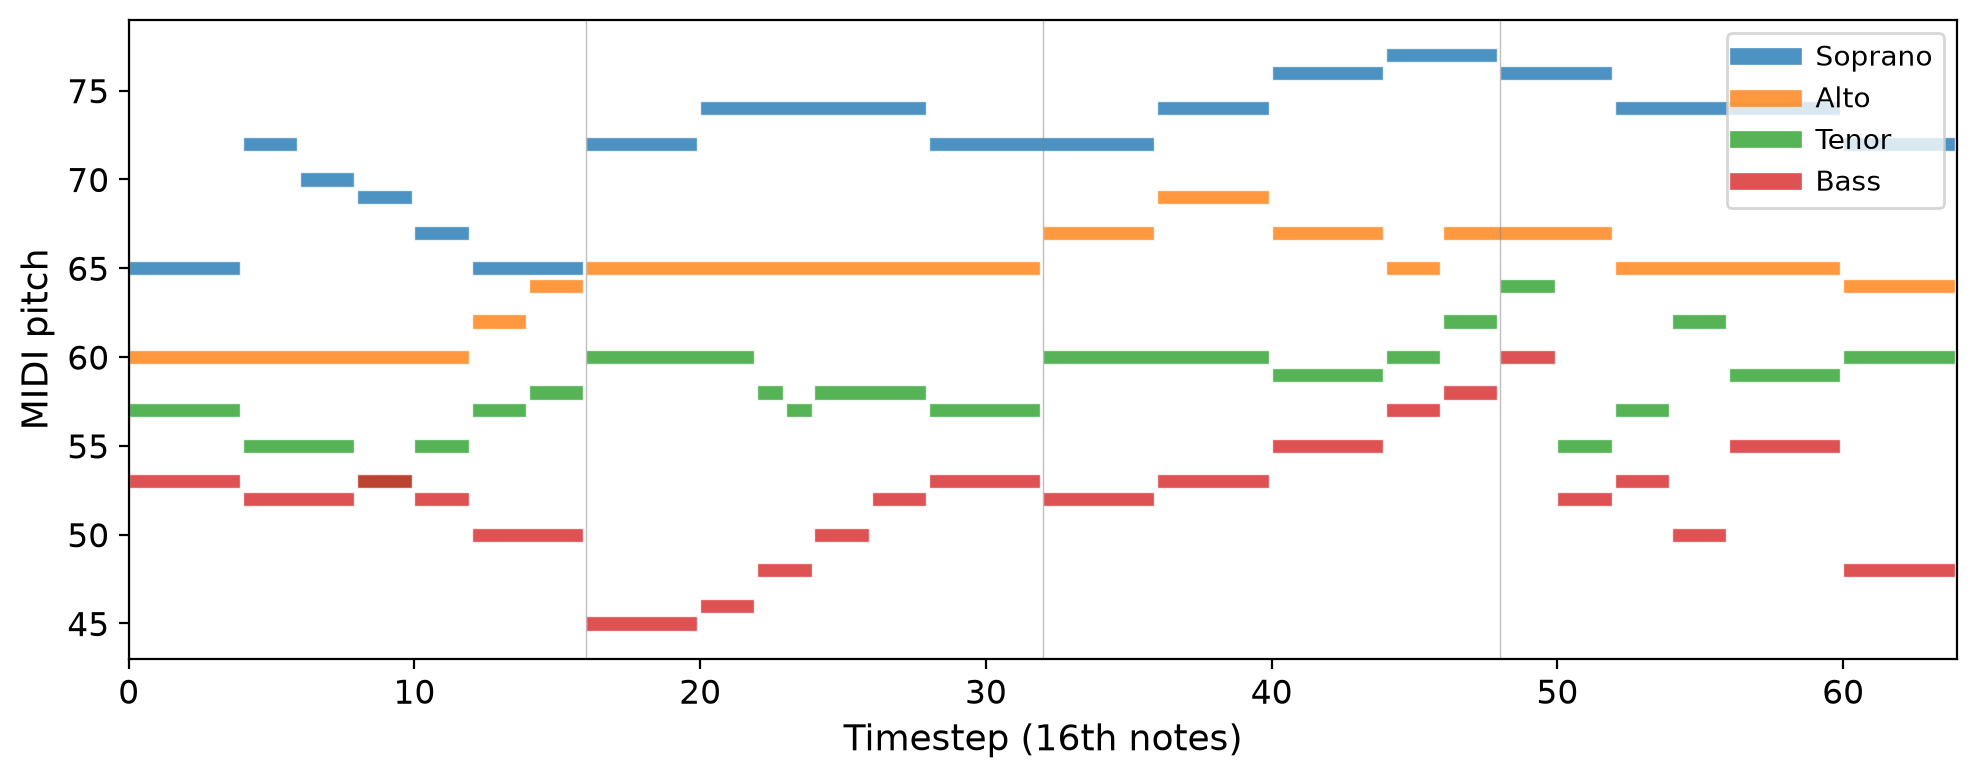

Saved: piano_roll_bach.pdf / .png


In [10]:
# Piano roll visualization of an excerpt of a Bach chorale

# Select a test chorale and take the first 64 timesteps (~4 bars)
chorale = [tuple(int(p) for p in ts) for ts in data['test'][0]][:64]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # S, A, T, B
labels = ['Soprano', 'Alto', 'Tenor', 'Bass']

fig, ax = plt.subplots(figsize=(10, 4))

for v in range(4):
    # Extract pitch sequence for this voice
    seq = [ts[v] if len(ts) > v else None for ts in chorale]
    
    # Group consecutive identical pitches into held notes
    i = 0
    while i < len(seq):
        if seq[i] is None:
            i += 1
            continue
        start, pitch = i, seq[i]
        while i < len(seq) and seq[i] == pitch:
            i += 1
        ax.add_patch(patches.Rectangle(
            (start, pitch - 0.4), i - start - 0.1, 0.8,
            facecolor=colors[v], alpha=0.8, edgecolor='white', linewidth=0.5
        ))

# Vertical bar lines every 16 steps
for b in range(0, len(chorale) + 1, 16):
    ax.axvline(b, color='grey', linewidth=0.5, alpha=0.5)

ax.set_xlim(0, len(chorale))
pitches = [p for ts in chorale for p in ts if p is not None]
ax.set_ylim(min(pitches) - 2, max(pitches) + 2)
ax.set_xlabel('Timestep (16th notes)')
ax.set_ylabel('MIDI pitch')
#ax.set_title('Piano roll of a Bach chorale excerpt (4 bars)')

# Legend
for v in range(4):
    ax.plot([], [], color=colors[v], linewidth=6, label=labels[v], alpha=0.8)
ax.legend(loc='upper right', fontsize=10)
ax.tick_params(labelsize=12)
ax.xaxis.label.set_size(13)
ax.yaxis.label.set_size(13)

plt.tight_layout()
plt.savefig('piano_roll_bach.pdf', bbox_inches='tight')
plt.savefig('piano_roll_bach.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: piano_roll_bach.pdf / .png')

#### 8. Statistical significance
The Mann-Whitney U test is applied on each metric (except cadence quality) for validation of the results. Mann-Whitney U is used because it does not assume the data is normally distributed. Rather it measures how much two groups differ from each other, which is appropriate here because the metric values are heavily skewed. Real Bach is compared to the generated chorales, and to the shuffled chorales.

Fisher's exact test is used for the cadence quality metric, because it is a binary metric.

In [11]:
# Statistical validation: Mann-Whitney U with rank-biserial effect sizes,
# Fisher's exact test for cadence, and Holm-Bonferroni correction over all tests.

# Calculate the Mann-Whitney U values for each distributional metric
def mw_test(a, b):
    # Drops the chorales that were assigned NaN
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    
    # Mann Whitney U
    u, p = mannwhitneyu(a, b)
    
    # Rank-biserial correlation r = 1 - 2U/(n1*n2)
    r = 1 - 2 * u / (len(a) * len(b))
    return p, r

# Holm-Bonferroni correction
def holm(pvals):
    m = len(pvals)
    order = np.argsort(pvals)
    adjusted = np.empty(m)
    running_max = 0.0
    for rank, idx in enumerate(order):
        running_max = max(running_max, (m - rank) * pvals[idx])
        adjusted[idx] = min(running_max, 1.0)       # Clipped at 1
    return adjusted

# Collect all tests as (metric, comparison, p, |r|)
rows = []

# Distributional metrics
for metric in ['pitch_class_entropy', 'scale_consistency', 'polyphony', 'pitch_range']:
    for comp, other in [('shuf', dist_shuf[metric]), ('gen', dist_gen[metric])]:
        p, r = mw_test(dist_real[metric], other)
        rows.append((metric, comp, p, abs(r)))

# Rule-based and segment-boundary metrics
for name, real, shuf, gen in [
    ('voice_crossing_rate', vc_real, vc_shuf, vc_gen),
    ('parallel_fifths_rate', pf_real, pf_shuf, pf_gen),
    ('boundary_interval', boundary_real, boundary_shuf, boundary_gen),
    ('within_interval', within_real, within_shuf, within_gen),
]:
    for comp, other in [('shuf', shuf), ('gen', gen)]:
        p, r = mw_test(real, other)
        rows.append((name, comp, p, abs(r)))

# Fisher's exact test for cadence quality (binary metric)
for comp, other in [('shuf', cad_shuf), ('gen', cad_gen)]:
    table = [
        [sum(cad_real), len(cad_real) - sum(cad_real)],
        [sum(other), len(other) - sum(other)]
    ]
    odds_ratio, p = fisher_exact(table)
    rows.append((f'cadence_quality (OR={odds_ratio:.1f})', comp, p, None))

# Holm-Bonferroni correction over the full family of tests
p_holm = holm(np.array([p for _, _, p, _ in rows]))

# Print results
def fmt_p(p):
    return f'{p:.3f}' if p >= 0.001 else '<0.001'

header = f'{"Metric":<32} {"raw p":>8} {"Holm p":>8} {"|r_rb|":>7} {"sig":>4}'
print(header)
print('-' * len(header))
for comp_label in ['shuf', 'gen']:
    print(f'\n--- Real vs {"Shuffled" if comp_label == "shuf" else "Generated"} ---')
    for (name, comp, p, r), ph in zip(rows, p_holm):
        if comp != comp_label:
            continue
        r_str = f'{r:.3f}' if r is not None else '--'
        sig = '*' if ph < 0.05 else ''
        print(f'{name:<32} {fmt_p(p):>8} {fmt_p(ph):>8} {r_str:>7} {sig:>4}')

Metric                              raw p   Holm p  |r_rb|  sig
---------------------------------------------------------------

--- Real vs Shuffled ---
pitch_class_entropy                 0.817    1.000   0.022     
scale_consistency                   0.868    1.000   0.016     
polyphony                           1.000    1.000   0.000     
pitch_range                         1.000    1.000   0.000     
voice_crossing_rate                 1.000    1.000   0.000     
parallel_fifths_rate               <0.001   <0.001   0.864    *
boundary_interval                  <0.001   <0.001   0.840    *
within_interval                     1.000    1.000   0.000     
cadence_quality (OR=9.1)            0.001    0.016      --    *

--- Real vs Generated ---
pitch_class_entropy                 0.249    1.000   0.108     
scale_consistency                   0.002    0.021   0.290    *
polyphony                          <0.001   <0.001   0.395    *
pitch_range                         0.004    0.038 

#### 9. Summary table

In [12]:
# Summary of all results

print(f'{"Metric":<25} {"Real Bach":>10} {"Shuffled":>10} {"Generated":>10}')
print('-' * 58)

print('Distributional metrics:')
for metric in ['pitch_class_entropy', 'scale_consistency', 'pitch_range', 'polyphony']:
    print(f'  {metric:<23} {dist_real[metric].mean():>10.4f} {dist_shuf[metric].mean():>10.4f} {dist_gen[metric].mean():>10.4f}')

print()
print('Rule-based metrics:')
print(f'  {"voice_crossing_rate":<23} {np.mean(vc_real):>10.4f} {np.mean(vc_shuf):>10.4f} {np.mean(vc_gen):>10.4f}')
print(f'  {"parallel_fifths_rate":<23} {np.mean(pf_real):>10.4f} {np.mean(pf_shuf):>10.4f} {np.mean(pf_gen):>10.4f}')
print(f'  {"cadence_quality":<23} {sum(cad_real)/len(cad_real):>10.4f} {sum(cad_shuf)/len(cad_shuf):>10.4f} {sum(cad_gen)/len(cad_gen):>10.4f}')

print()
print('Model likelihood:')
print(f'  {"NLL":<23} {nll_real:>10.4f} {nll_shuf:>10.4f} {"-":>10}')
print(f'  {"Perplexity":<23} {ppl_real:>10.4f} {ppl_shuf:>10.4f} {"-":>10}')

print()
print('Segment-boundary intervals:')
for name, w, b in [
    ('Real Bach', within_real, boundary_real),
    ('Shuffled', within_shuf, boundary_shuf),    
    ('Generated', within_gen, boundary_gen),
]:
    print(f'  {name:<23} within: {np.nanmean(w):.3f}  boundary: {np.nanmean(b):.3f}  ratio: {np.nanmean(b)/np.nanmean(w):.2f}')

print()
print(f'{"piece_length (mean)":<25} {np.mean(real_lengths):>10.1f} {np.mean(real_lengths):>10.1f} {np.mean(gen_lengths):>10.1f}')

Metric                     Real Bach   Shuffled  Generated
----------------------------------------------------------
Distributional metrics:
  pitch_class_entropy         3.0260     3.0209     2.9850
  scale_consistency           0.9297     0.9301     0.9032
  pitch_range                34.3506    34.3506    32.6104
  polyphony                   3.9231     3.9231     3.8173

Rule-based metrics:
  voice_crossing_rate         0.0211     0.0211     0.1422
  parallel_fifths_rate        0.0004     0.0026     0.0059
  cadence_quality             0.9740     0.8052     0.2208

Model likelihood:
  NLL                         0.5583     0.6167          -
  Perplexity                  1.7477     1.8528          -

Segment-boundary intervals:
  Real Bach               within: 0.342  boundary: 1.829  ratio: 5.35
  Shuffled                within: 0.342  boundary: 3.595  ratio: 10.52
  Generated               within: 0.457  boundary: 2.139  ratio: 4.68

piece_length (mean)            245.5      245.